In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/s-and-p-500-stock-price-daily-till-2025-13-march/spx_d.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:


df = pd.read_csv("/kaggle/input/s-and-p-500-stock-price-daily-till-2025-13-march/spx_d.csv")


In [4]:
df = df[["Date", "Close"]]

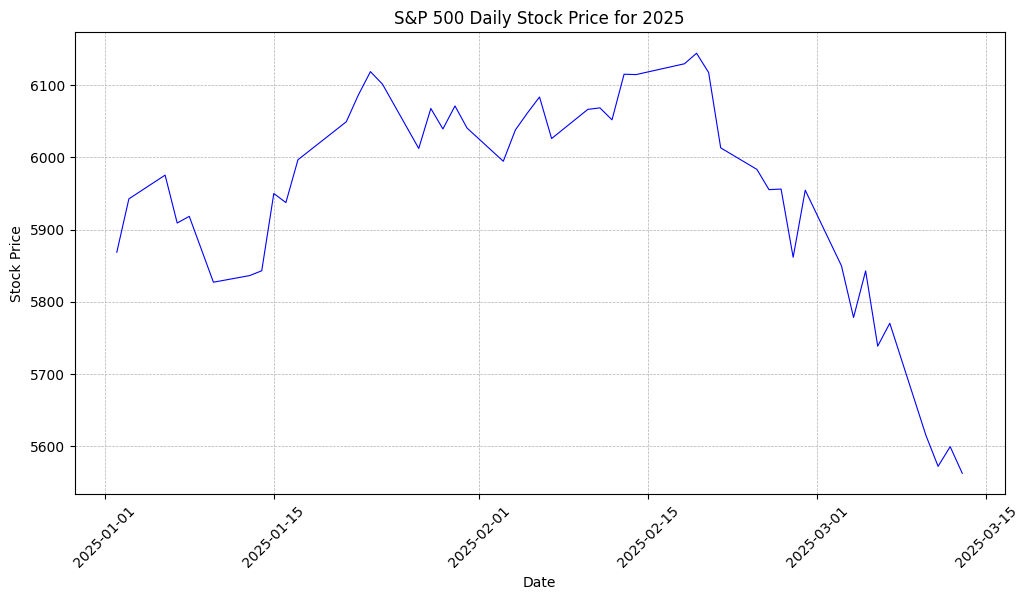

In [5]:


# Convert date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Filter the last year's data
last_year = df["Date"].max().year
df_last_year = df[df["Date"].dt.year == last_year]

# Plot the stock price
plt.figure(figsize=(12, 6))
plt.plot(df_last_year["Date"], df_last_year['Close'], linewidth=0.8, color='blue')
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title(f"S&P 500 Daily Stock Price for {last_year}")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()


In [6]:
df.describe()

,Date,Close
count,39403,39403.000000
mean,1948-11-08 04:40:13.826358400,417.436964
min,1789-05-01 00:00:00,0.490000
25%,1914-02-02 12:00:00,8.870000
50%,1947-07-11 00:00:00,18.380000
75%,1986-02-05 12:00:00,213.880000
max,2025-03-13 00:00:00,6144.150000
std,NaN,930.376108


In [7]:
df.dtypes

Date     datetime64[ns]
Close           float64
dtype: object

In [8]:
df.index = df.pop("Date")

In [9]:
df

,Close
Date,
1789-05-01,0.51
1789-06-01,0.51
1789-07-01,0.50
1789-08-01,0.51
1789-09-01,0.51
...,...
2025-03-07,5770.20
2025-03-10,5614.56
2025-03-11,5572.07


In [10]:
start_date = "2024-01-01"
end_date = "2025-03-15"

# Filter the DataFrame
df_filtered = df.loc[start_date:end_date]


In [11]:
df_filtered.tail()

,Close
Date,
2025-03-07,5770.20
2025-03-10,5614.56
2025-03-11,5572.07
2025-03-12,5599.30
2025-03-13,5562.45


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_filtered = df_filtered.copy()
df_filtered['Close'] = scaler.fit_transform(df_filtered[['Close']])


In [13]:
df_filtered

,Close
Date,
2024-01-02,0.037204
2024-01-03,0.011082
2024-01-04,0.000000
2024-01-05,0.005881
2024-01-08,0.051434
...,...
2025-03-07,0.743073
2025-03-10,0.636138
2025-03-11,0.606945


In [14]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [15]:
import numpy as np
import pandas as pd
import datetime

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
    """
    Converts a time series DataFrame into a windowed dataset with optimized performance.

    Parameters:
    dataframe (pd.DataFrame): Time series DataFrame with 'Date' as index and 'Close' as values.
    first_date_str (str): Start date in 'YYYY-MM-DD' format.
    last_date_str (str): End date in 'YYYY-MM-DD' format.
    n (int): Window size (number of past observations for each row).

    Returns:
    pd.DataFrame: Windowed dataset with sequential input-output for time series modeling.
    """
    # Convert string dates to datetime
    first_date = pd.to_datetime(first_date_str)
    last_date = pd.to_datetime(last_date_str)

    # Ensure index is a DateTimeIndex
    dataframe = dataframe.copy()
    dataframe.index = pd.to_datetime(dataframe.index)

    # Filter data within the date range
    df_filtered = dataframe.loc[first_date:last_date]

    # Extract values as a NumPy array for faster slicing
    values = df_filtered['Close'].to_numpy()
    dates = df_filtered.index.to_numpy()

    # Use NumPy's sliding window view for fast window creation
    from numpy.lib.stride_tricks import sliding_window_view
    X = sliding_window_view(values, window_shape=n+1)

    # Extract features (X) and targets (y)
    X_features, y_target = X[:, :-1], X[:, -1]

    # Trim corresponding dates (align with windowing)
    target_dates = dates[n:]

    # Create DataFrame
    ret_df = pd.DataFrame(X_features, columns=[f'Target-{n-i}' for i in range(n)])
    ret_df.insert(0, 'Target Date', target_dates)
    ret_df['Target'] = y_target

    return ret_df

# Example usage:
windowed_df = df_to_windowed_df(df_filtered, '2024-01-08', '2025-03-15', n=3)



In [16]:
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2024-01-11,0.051434,0.046597,0.065113,0.062908
1,2024-01-12,0.046597,0.065113,0.062908,0.065374
2,2024-01-16,0.065113,0.062908,0.065374,0.053110
3,2024-01-17,0.062908,0.065374,0.053110,0.034717
4,2024-01-18,0.065374,0.053110,0.034717,0.063388
...,...,...,...,...,...
288,2025-03-07,0.748535,0.792837,0.721307,0.743073
289,2025-03-10,0.792837,0.721307,0.743073,0.636138
290,2025-03-11,0.721307,0.743073,0.636138,0.606945
291,2025-03-12,0.743073,0.636138,0.606945,0.625654


In [17]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

((293,), (293, 3, 1), (293,))

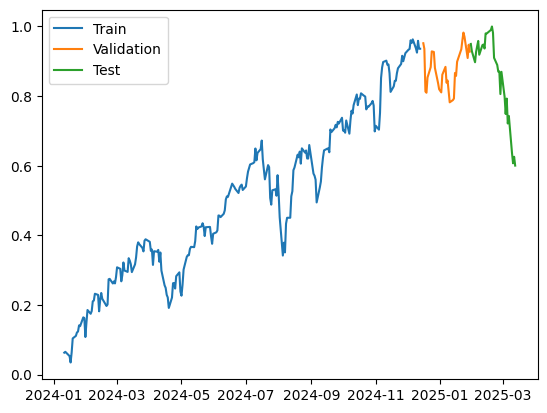

In [18]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(3, 1)),
    LSTM(100, return_sequences=True, input_shape=(3, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dense(25, activation='relu'),
    Dense(1)
])

optimizer = Adam(learning_rate=0.0001)
model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.3253 - mae: 0.5172 - val_loss: 0.7517 - val_mae: 0.8651
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3022 - mae: 0.4996 - val_loss: 0.7215 - val_mae: 0.8474
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2834 - mae: 0.4850 - val_loss: 0.6940 - val_mae: 0.8310
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2706 - mae: 0.4656 - val_loss: 0.6672 - val_mae: 0.8148
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2417 - mae: 0.4404 - val_loss: 0.6392 - val_mae: 0.7975
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2241 - mae: 0.4199 - val_loss: 0.6102 - val_mae: 0.7791
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2433 - mae: 0.4407 - val_loss: 0.5791 - val_mae: 0.7589
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2216 - mae: 0.4174 - val_loss: 0.5462 - val_mae: 0.7369
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2173 - mae: 

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


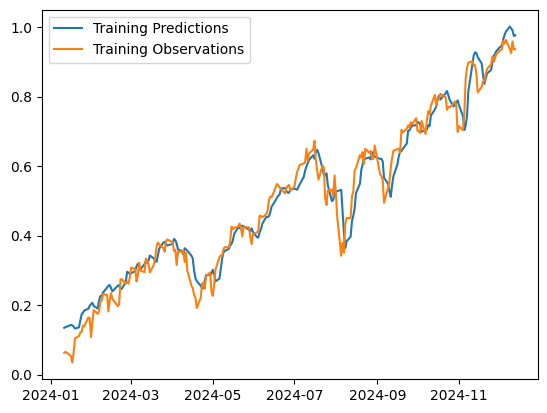

In [21]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


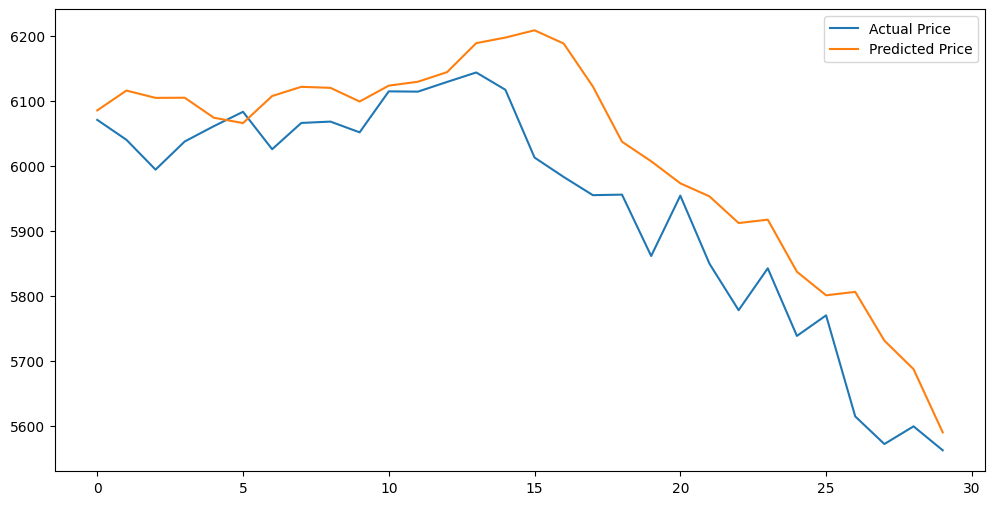

In [22]:
# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual Price")
plt.plot(y_pred_inv, label="Predicted Price")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


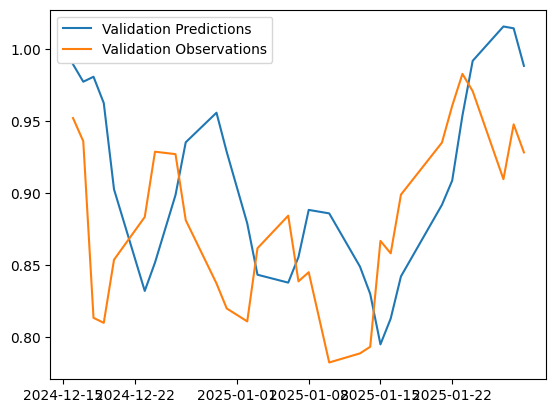

In [23]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


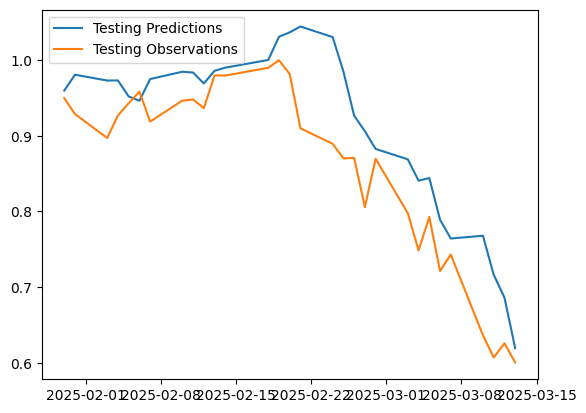

In [24]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

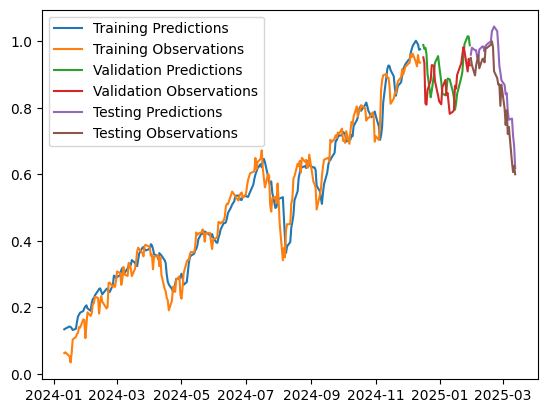

In [25]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'])